Generate text vs generate images: two API calls

In [9]:
import google.generativeai as genai
import os
from google.colab import userdata



API_KEY = userdata.get('GEMINI_API_KEY')
genai.configure(api_key=API_KEY)
prompt = 'A lake view from a banayan tree'
full_instruction = f'Describe this scence vividly in 3 sentences. {prompt}'


print("Text Generation")
model = genai.GenerativeModel('gemini-2.5-flash', generation_config={'max_output_tokens':150, 'temperature':0.7})

response = model.generate_content(full_instruction)
print(f'Response: {response.text}')

usage = response.usage_metadata
print(f"Prompt (Input) Tokens: {usage.prompt_token_count}")
print(f"Candidates (Output) Tokens: {usage.candidates_token_count}")
print(f"Total Tokens Used: {usage.total_token_count}")



print("Image Generation")
print("\n" + "=" * 60)
print("IMAGE GENERATION (Diffusion)")
print("=" * 60)

image_response = client.images.generate(
    model="dall-e-3",
    prompt=prompt,
    size="1024x1024",
    quality="standard",
    n=1
)

print(f"Prompt: {prompt}")
print(f"Image URL: {image_response.data[0].url}")
print(f"Revised prompt: {image_response.data[0].revised_prompt}")

SyntaxError: unterminated string literal (detected at line 28) (3272338057.py, line 28)

### Listing available models

In [ ]:
print("Available Models:")
for m in genai.list_models():
  if 'generateContent' in m.supported_generation_methods:
    print(f"  Model Name: {m.name}, Supported Methods: {m.supported_generation_methods}")

Diffusion vs GAN: speed and quality trade-off


In [ ]:
!pip install diffusers torch transformers accelerate

In [4]:
import torch
import time
from huggingface_hub import login
from google.colab import userdata

print(f'Standard Diffusion')
from diffusers import StableDiffusionPipeline

hf_token = userdata.get('HF_TOKEN')
if hf_token:
    login(token=hf_token)
else:
    print("Please add your Hugging Face token")

pipe = StableDiffusionPipeline.from_pretrained(
    'runwayml/stable-diffusion-v1-5',
    torch_dtype = torch.float16
).to('cuda')

prompt = 'A photorealistic mountain view from bank of river'
start = time.time()
image_50 = pipe(prompt, num_inference_steps=50).images[0]
time_50 = time.time() - start

print(f'50 Steps: {time_50:.1f}s')
image_50.save('diffusion_50_img.png')

Standard Diffusion


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

50 Steps: 7.4s


In [3]:
import torch
import time
from huggingface_hub import login
from google.colab import userdata

print(f'Standard Diffusion: Reduced Denoising Steps (10)')
from diffusers import StableDiffusionPipeline

hf_token = userdata.get('HF_TOKEN')
if hf_token:
    login(token=hf_token)
else:
    print("Please add your Hugging Face token")

pipe = StableDiffusionPipeline.from_pretrained(
    'runwayml/stable-diffusion-v1-5',
    torch_dtype = torch.float16
).to('cuda')


prompt = 'A photorealistic mountain view from bank of river'
image_10 = pipe(prompt,num_inference_steps=10).images[0]
time_10 = time.time() - start

print(f'10 Steps: {time_10:.1f}s')
image_10.save('diffusion_10_img.png')

Standard Diffusion: Reduced Denoising Steps (10)


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

10 Steps: 310.1s


Compare the saved Images and Quality

**Latent space interpolation (VAE)**

Interpolate between two data points in VAE latent space to see smooth morphing



Training VAE on MNIST (this takes ~2 minutes on CPU)...


100%|██████████| 9.91M/9.91M [00:00<00:00, 20.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 540kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.49MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.29MB/s]


Epoch 1/5, Loss: 172.1
Epoch 2/5, Loss: 176.1
Epoch 3/5, Loss: 157.9
Epoch 4/5, Loss: 161.1
Epoch 5/5, Loss: 154.2


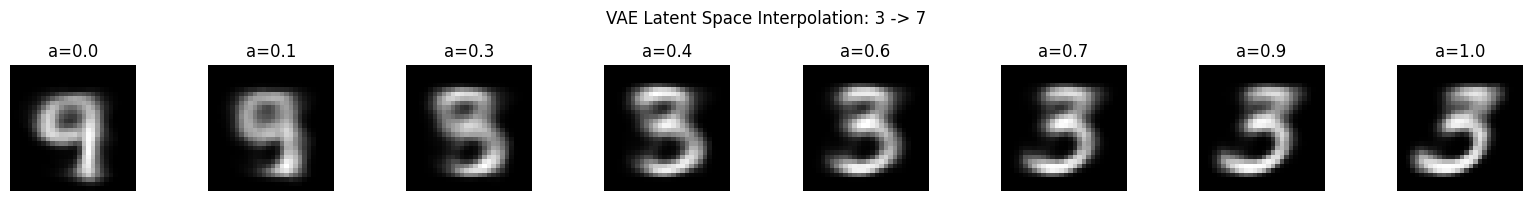

In [1]:
# ============================================================
# VAE LATENT SPACE INTERPOLATION
# See how VAEs enable smooth generation between two points
# ============================================================
# pip install torch torchvision matplotlib
# Works on CPU (MNIST is small)
# ============================================================

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# 1. DEFINE A SIMPLE VAE
# ============================================================

class SimpleVAE(nn.Module):
    def __init__(self, latent_dim=2):
        super().__init__()
        self.latent_dim = latent_dim
        # Encoder: 784 -> 256 -> (mu, logvar)
        self.encoder = nn.Sequential(
            nn.Linear(784, 256), nn.ReLU()
        )
        self.fc_mu = nn.Linear(256, latent_dim)
        self.fc_logvar = nn.Linear(256, latent_dim)
        # Decoder: latent_dim -> 256 -> 784
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256), nn.ReLU(),
            nn.Linear(256, 784), nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder(x.view(-1, 784))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z).view(-1, 1, 28, 28)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

# ============================================================
# 2. INTERPOLATE IN LATENT SPACE
# ============================================================
print("Training VAE on MNIST (this takes ~2 minutes on CPU)...")

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Load MNIST
transform = transforms.Compose([transforms.ToTensor()])
mnist = datasets.MNIST('./data', train=True, download=True, transform=transform)
loader = DataLoader(mnist, batch_size=128, shuffle=True)

# Train (simplified - just a few epochs for demo)
vae = SimpleVAE(latent_dim=2)
optimizer = torch.optim.Adam(vae.parameters(), lr=1e-3)

for epoch in range(5):
    for batch, _ in loader:
        recon, mu, logvar = vae(batch)
        recon_loss = nn.functional.binary_cross_entropy(
            recon, batch, reduction='sum'
        )
        kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        loss = recon_loss + kl_loss
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}/5, Loss: {loss.item()/len(batch):.1f}")

# ============================================================
# 3. INTERPOLATE BETWEEN TWO DIGITS
# ============================================================
vae.eval()
with torch.no_grad():
    # Encode two different digits
    digit_3 = mnist[2][0].unsqueeze(0)  # A '3'
    digit_7 = mnist[7][0].unsqueeze(0)  # A '7'

    mu_3, _ = vae.encode(digit_3)
    mu_7, _ = vae.encode(digit_7)

    # Linear interpolation in latent space
    steps = 8
    fig, axes = plt.subplots(1, steps, figsize=(16, 2))
    for i, alpha in enumerate(np.linspace(0, 1, steps)):
        z = (1 - alpha) * mu_3 + alpha * mu_7  # Interpolate
        img = vae.decode(z).squeeze().numpy()
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(f"a={alpha:.1f}")
        axes[i].axis('off')

    plt.suptitle("VAE Latent Space Interpolation: 3 -> 7")
    plt.tight_layout()
    plt.savefig("vae_interpolation.png", dpi=150)
    plt.show()

# ============================================================
# KEY INSIGHT: The VAE's continuous latent space allows smooth
# transitions between data points. This is impossible with GANs
# (discontinuous) or diffusion (no explicit latent space).
# This property makes VAEs ideal for drug discovery, music
# generation, and any domain needing controlled exploration.
# ============================================================